# Lab 5: Linear Regression — Predicting House Prices

Name : Nainsy Chawla

Student ID : 023-24-0261

Section : H

GitHub Profile : https://github.com/Nainsy-chawla/ML_Lab_Practise

Kaggle Profile : https://www.kaggle.com/nainsychawla

Dataset : House Prices – Ames Housing Dataset

Dataset Source: Kaggle – House Prices: Advanced Regression Techniques

# Part 1 — Dataset, Problem & Feature/Target Identification 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
# Task1
df = pd.read_csv("train.csv")

print("Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nSummary Statistics:")
display(df.describe())

Shape: (1460, 81)

First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 1

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Interpretation:
The dataset contains 1,460 house records and 81 columns, including the target variable SalePrice and the house features. The dataset contains both numerical and categorical variables. The first few rows show different characteristics of houses, while the summary statistics provide information about the numerical features such as their mean, minimum, maximum, and quartiles.

In [3]:
# Task 2
target = "SalePrice"
feature_df = df.drop(columns=[target, "Id"])          # Id is only an identifier

# MSSubClass is a category code stored as a number
categorical_features = feature_df.select_dtypes(exclude=np.number).columns.tolist() + ["MSSubClass"]
numerical_features = [c for c in feature_df.select_dtypes(include=np.number).columns if c != "MSSubClass"]

print("Dependent variable:", target)
print("\nNumerical independent variables:", len(numerical_features)); print(numerical_features)
print("\nCategorical independent variables:", len(categorical_features)); print(categorical_features)

Dependent variable: SalePrice

Numerical independent variables: 35
['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']

Categorical independent variables: 44
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'Kitch

Interpretation:
The dependent variable is SalePrice. Excluding the identifier Id, there are 79 independent variables: 35 numerical and 44 categorical. MSSubClass is stored as a number but is really a category code, so it is counted as categorical.

Task 3
 
Interpretation:
This is a regression problem because the target variable SalePrice is a continuous numerical value that can take many different values. Therefore, the model predicts a numerical price rather than assigning a class. Regression metrics such as MAE, MSE, RMSE, and R² are used to evaluate the predictions.

# Part 2 — Data Preparation & Train/Test Split

In [4]:
# Task 4
selected_features = [
    "GrLivArea",
    "OverallQual",
    "TotalBsmtSF",
    "GarageCars",
    "YearBuilt",
    "FullBath",
    "1stFlrSF",
    "GarageArea",
    "Neighborhood",
    "HouseStyle",
    "KitchenQual"
]

X = df[selected_features].copy()
y = df["SalePrice"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.head())
categorical_cols = [
    "Neighborhood",
    "HouseStyle",
    "KitchenQual"
]
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

print("Shape after encoding:", X.shape)

display(X.head())

X shape: (1460, 11)
y shape: (1460,)


,GrLivArea,OverallQual,TotalBsmtSF,GarageCars,YearBuilt,FullBath,1stFlrSF,GarageArea,Neighborhood,HouseStyle,KitchenQual
0,1710,7,856,2,2003,2,856,548,CollgCr,2Story,Gd
1,1262,6,1262,2,1976,2,1262,460,Veenker,1Story,TA
2,1786,7,920,2,2001,2,920,608,CollgCr,2Story,Gd
3,1717,7,756,3,1915,1,961,642,Crawfor,2Story,Gd
4,2198,8,1145,3,2000,2,1145,836,NoRidge,2Story,Gd


0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64

Shape after encoding: (1460, 42)


,GrLivArea,OverallQual,TotalBsmtSF,GarageCars,YearBuilt,FullBath,1stFlrSF,GarageArea,Neighborhood_Blueste,Neighborhood_BrDale,...,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA
0,1710,7,856,2,2003,2,856,548,0,0,...,0,0,0,0,1,0,0,0,1,0
1,1262,6,1262,2,1976,2,1262,460,0,0,...,0,1,0,0,0,0,0,0,0,1
2,1786,7,920,2,2001,2,920,608,0,0,...,0,0,0,0,1,0,0,0,1,0
3,1717,7,756,3,1915,1,961,642,0,0,...,0,0,0,0,1,0,0,0,1,0
4,2198,8,1145,3,2000,2,1145,836,0,0,...,0,0,0,0,1,0,0,0,1,0


Interpretation : Neighborhood and HouseStyle are nominal, meaning they have no natural order, so one-hot encoding is appropriate. If I used integer codes, the model would wrongly treat "level 3" as three times "level 1". KitchenQual is ordinal (Ex > Gd > TA > Fa), so an ordered integer mapping would also have worked and uses fewer columns, but I used one-hot so that each quality level gets its own coefficient without assuming equal spacing between levels. I used drop_first=True to remove one dummy per column, which avoids perfect multicollinearity with the intercept; the dropped level becomes the reference category. The 11 selected features became 42 numeric columns.

In [5]:
# Task 5
print("Are all columns numeric?")
print(X.dtypes.value_counts())

print("\nTotal missing values:")
print(X.isnull().sum().sum())

Are all columns numeric?
int64    42
Name: count, dtype: int64

Total missing values:
0


Interpretation:
After one-hot encoding, all 42 feature columns are numeric with int64 data type. The dataset also contains zero missing values in X. Therefore, the prepared feature matrix satisfies the input requirements for the Linear Regression model and does not require additional missing-value handling.

In [6]:
# Task 6
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1168, 42)
X_test : (292, 42)
y_train: (1168,)
y_test : (292,)


Interpretation : The dataset was divided into training and testing sets using an 80/20 split. The training set contains 1,168 houses and the testing set contains 292 houses. Both sets contain the same 42 prepared features. The training data will be used to train the Linear Regression model, while the test data will be kept separate to evaluate the model on unseen houses.

# Part 3 — Linear Regression & Predictions 

In [7]:
# Task 7
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


Interpretation: The Linear Regression model was successfully trained on the house price dataset. It learned the relationship between the selected features and the target variable, SalePrice, and was used to predict house prices for the test set.

In [8]:
# Task 8
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])
comparison = pd.DataFrame({
    "Actual Price": y_test.values[:10],
    "Predicted Price": y_pred[:10]
})

display(comparison)

First 10 predictions:
[138672.59919713 323302.91259617 113402.87687294 175295.92368626
 317235.49371296  68057.35435414 234614.74918772 144773.82943043
  67650.27131547 117523.02371835]


,Actual Price,Predicted Price
0,154500,138672.599197
1,325000,323302.912596
2,115000,113402.876873
3,159000,175295.923686
4,315500,317235.493713
5,75500,68057.354354
6,311500,234614.749188
7,146000,144773.829430
8,84500,67650.271315
9,135500,117523.023718


Interpretation: The model successfully predicted house prices for the test data. The comparison of actual and predicted prices shows that the model produces reasonably close predictions for several houses, while some predictions have larger errors. This indicates that the model has learned useful patterns from the training data but does not predict every house price perfectly.

# Part 4 — Coefficients & Intercept

In [9]:
# Task 9
coef_table = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})

# drop_first=True removes the first (alphabetical) level of each categorical column
reference = {c: sorted(df[c].dropna().unique())[0] for c in categorical_cols}

numeric_units = {
    "GrLivArea":   "each additional square foot of above-ground living area",
    "OverallQual": "each one-point increase in overall quality (1–10 scale)",
    "TotalBsmtSF": "each additional square foot of basement area",
    "GarageCars":  "each additional car of garage capacity",
    "YearBuilt":   "each year newer the house was built",
    "FullBath":    "each additional full bathroom",
    "1stFlrSF":    "each additional square foot of first-floor area",
    "GarageArea":  "each additional square foot of garage area",
}

def interpret(feature, coef):
    direction = "an increase" if coef > 0 else "a decrease"
    amount = f"${abs(coef):,.0f}"
    if feature in numeric_units:
        return (f"{numeric_units[feature]} is associated with a {direction} of "
                f"about {amount} in predicted price, holding other features constant")
    col, level = feature.split("_", 1)
    return (f"{col} = {level} is associated with a {direction} of about {amount} "
            f"compared with the reference level ({reference[col]}), holding other features constant")

coef_table["Interpretation"] = [interpret(f, c) for f, c in zip(coef_table["Feature"], coef_table["Coefficient"])]
coef_table = coef_table.sort_values("Coefficient", ascending=False).reset_index(drop=True)

pd.set_option("display.max_colwidth", None)
display(coef_table)
print(f"Intercept: {model.intercept_:,.2f}")

,Feature,Coefficient,Interpretation
0,Neighborhood_NoRidge,75987.009138,"Neighborhood = NoRidge is associated with a an increase of about $75,987 compared with the reference level (Blmngtn), holding other features constant"
1,Neighborhood_StoneBr,63701.207398,"Neighborhood = StoneBr is associated with a an increase of about $63,701 compared with the reference level (Blmngtn), holding other features constant"
2,Neighborhood_NridgHt,58504.507383,"Neighborhood = NridgHt is associated with a an increase of about $58,505 compared with the reference level (Blmngtn), holding other features constant"
3,Neighborhood_Veenker,57477.008561,"Neighborhood = Veenker is associated with a an increase of about $57,477 compared with the reference level (Blmngtn), holding other features constant"
4,Neighborhood_ClearCr,53095.783784,"Neighborhood = ClearCr is associated with a an increase of about $53,096 compared with the reference level (Blmngtn), holding other features constant"
5,Neighborhood_Crawfor,46840.913185,"Neighborhood = Crawfor is associated with a an increase of about $46,841 compared with the reference level (Blmngtn), holding other features constant"
6,Neighborhood_Timber,37524.751982,"Neighborhood = Timber is associated with a an increase of about $37,525 compared with the reference level (Blmngtn), holding other features constant"
7,Neighborhood_Somerst,31196.968912,"Neighborhood = Somerst is associated with a an increase of about $31,197 compared with the reference level (Blmngtn), holding other features constant"
8,Neighborhood_Gilbert,24360.245441,"Neighborhood = Gilbert is associated with a an increase of about $24,360 compared with the reference level (Blmngtn), holding other features constant"
9,Neighborhood_CollgCr,23630.382943,"Neighborhood = CollgCr is associated with a an increase of about $23,630 compared with the reference level (Blmngtn), holding other features constant"


Intercept: -394,548.38


Interpretation:
The table lists every feature's coefficient with a plain-English reading. For numerical features, the coefficient is the change in predicted price for a one-unit increase, holding the other features constant (for example, each additional OverallQual point is associated with about $13,021 higher predicted price). For one-hot columns, the coefficient is the difference from the reference category, which is Blmngtn for Neighborhood, 1.5Fin for HouseStyle and Ex (Excellent) for KitchenQual. For example, Neighborhood_NoRidge is associated with about $75,987 higher predicted price than Blmngtn. All three KitchenQual dummies are large and negative (roughly −$45k to −$54k) because they are measured against Excellent kitchens.

In [10]:
# Task 10
print(f"Intercept = {model.intercept_:,.2f}")

Intercept = -394,548.38


Interpretation: The intercept is -$394,548.38. It does not have a sensible real-world interpretation because it represents the predicted house price when all numerical features are zero and all categorical dummy variables are at their reference levels. Such a combination does not represent a realistic house in the dataset. Therefore, the intercept should mainly be viewed as a mathematical component of the regression equation rather than an actual house price.

# Part 5 — Residuals & Regression Metrics

First 10 residuals:
892     15827.400803
1105     1697.087404
413      1597.123127
522    -16295.923686
1036    -1735.493713
614      7442.645646
218     76885.250812
1160     1226.170570
649     16849.728685
887     17976.976282
Name: SalePrice, dtype: float64


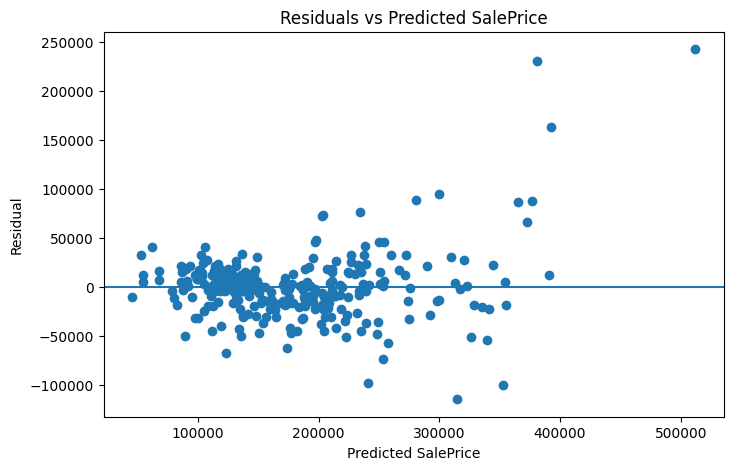

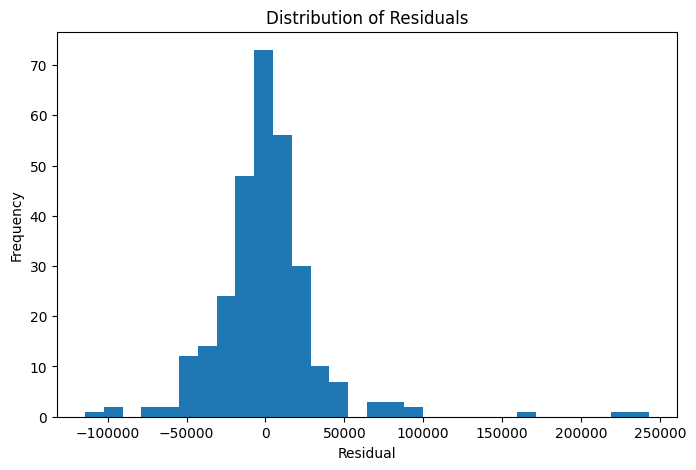

In [11]:
#Task 11
residuals = y_test - y_pred

print("First 10 residuals:")
print(residuals[:10])
plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted SalePrice")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted SalePrice")

plt.show()
plt.figure(figsize=(8, 5))

plt.hist(residuals, bins=30)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.show()

Interpretation:
The residuals are centred near zero, but they are not randomly scattered. The residuals-vs-predicted plot fans out (heteroscedasticity): errors are mostly within about ±$50k for houses predicted below roughly $200k, and they grow for more expensive houses. At high predicted prices the residuals are mostly positive, so the model systematically under-predicts expensive houses, and a few outliers exceed $200k. The histogram is peaked at zero but right-skewed with a long positive tail, which matches those under-predictions. This suggests a straight linear model on raw price fits the high end poorly, and a log-transformed target would likely help.

In [12]:
#Task 12
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

metrics_table = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Value": [mae, mse, rmse, r2]
})

display(metrics_table)

,Metric,Value
0,MAE,2.126436e+04
1,MSE,1.226512e+09
2,RMSE,3.502160e+04
3,R²,8.400964e-01


Interpretation

MAE = 21,264.36

On average, the model's predictions differ from the actual house prices by approximately $21,264.

MSE = 1.2265 × 10⁹

MSE measures the average squared prediction error. Because the errors are squared, larger errors have a much greater effect on this metric.

RMSE = 35,021.60

The model has a typical prediction error of approximately $35,022. RMSE gives more importance to large errors than MAE.

R² = 0.8401

The model explains approximately 84.01% of the variation in house prices in the test set.

Task 13 :

Interpretation:
I would show MAE to a non-technical stakeholder because it is the easiest metric to understand. An MAE of approximately 21,264 means that, on average, the model's predicted house price differs from the actual price by about $21,264. This gives a direct and understandable idea of the model's prediction error.

# Part 6 — Training vs. Testing & Generalization

In [13]:
#Task 14
train_pred = model.predict(X_train)
train_mae = mean_absolute_error(y_train, train_pred)

train_mse = mean_squared_error(y_train, train_pred)

train_rmse = np.sqrt(train_mse)

train_r2 = r2_score(y_train, train_pred)
comparison_metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Training": [
        train_mae,
        train_mse,
        train_rmse,
        train_r2
    ],
    "Testing": [
        mae,
        mse,
        rmse,
        r2
    ]
})

display(comparison_metrics)

,Metric,Training,Testing
0,MAE,2.061963e+04,2.126436e+04
1,MSE,1.052001e+09,1.226512e+09
2,RMSE,3.243456e+04,3.502160e+04
3,R²,8.236245e-01,8.400964e-01


Interpretation:
The model was evaluated on both the training and testing datasets. The training MAE and RMSE are slightly lower than the testing values, which is expected because the model was trained on the training data. The training R² is 0.8236, while the testing R² is 0.8401, showing that the model explains a similar amount of variation in both datasets.

Task 15

Interpretation:
Test MAE and RMSE are slightly higher than training (about $21.3k vs $20.6k MAE), but test R² (0.840) is slightly higher than training R² (0.824). That reversal is not a sign of overfitting. R² depends on how spread out the prices are: from the MSE and R² values, the test prices have a standard deviation of about $88k versus about $77k in training, so the same kind of error looks smaller relative to the variance. The gap in every metric is small, and performance did not drop on unseen data, so there is no evidence of overfitting. This is expected, since a plain linear model with 42 features and 1,168 training rows has low variance. Because this is a single 80/20 split, cross-validation would give a more reliable check.

# Part 7 — Final Model Analysis, Conclusion & Kaggle Submission

In [14]:
# Task 16
# A) Raw coefficients (from Part 4), ranked by absolute size
coef_table = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
coef_table["AbsoluteCoefficient"] = coef_table["Coefficient"].abs()

print("A) Top 10 by raw coefficient magnitude:")
display(coef_table.sort_values("AbsoluteCoefficient", ascending=False).head(10))

# B) Scale-adjusted: coefficient x standard deviation of the feature
#    = change in predicted price for a one-standard-deviation change in that feature
coef_table["Std_Dev"] = X_train.std().values
coef_table["Effect_per_1_SD"] = coef_table["Coefficient"] * coef_table["Std_Dev"]
coef_table["Abs_Effect"] = coef_table["Effect_per_1_SD"].abs()

print("\nB) Top 10 after adjusting for scale (effect of a 1-standard-deviation change):")
display(coef_table.sort_values("Abs_Effect", ascending=False)
        [["Feature", "Coefficient", "Std_Dev", "Effect_per_1_SD"]].head(10))

A) Top 10 by raw coefficient magnitude:


,Feature,Coefficient,AbsoluteCoefficient
22,Neighborhood_NoRidge,75987.009138,75987.009138
29,Neighborhood_StoneBr,63701.207398,63701.207398
23,Neighborhood_NridgHt,58504.507383,58504.507383
31,Neighborhood_Veenker,57477.008561,57477.008561
41,KitchenQual_TA,-53667.262298,53667.262298
11,Neighborhood_ClearCr,53095.783784,53095.783784
39,KitchenQual_Fa,-53068.108191,53068.108191
13,Neighborhood_Crawfor,46840.913185,46840.913185
40,KitchenQual_Gd,-44828.863732,44828.863732
30,Neighborhood_Timber,37524.751982,37524.751982



B) Top 10 after adjusting for scale (effect of a 1-standard-deviation change):


,Feature,Coefficient,Std_Dev,Effect_per_1_SD
0,GrLivArea,69.622452,524.432686,36512.289693
41,KitchenQual_TA,-53667.262298,0.500196,-26844.141615
40,KitchenQual_Gd,-44828.863732,0.490591,-21992.647932
1,OverallQual,13020.693586,1.367619,17807.351300
23,Neighborhood_NridgHt,58504.507383,0.222578,13021.805535
22,Neighborhood_NoRidge,75987.009138,0.165767,12596.137774
33,HouseStyle_1Story,19148.128942,0.500178,9577.477512
6,1stFlrSF,-23.284360,386.675268,-9003.486266
13,Neighborhood_Crawfor,46840.913185,0.190481,8922.324160
39,KitchenQual_Fa,-53068.108191,0.163308,-8666.443526


Interpretation:
After adjusting the coefficients for feature scale, GrLivArea, KitchenQual_TA, and KitchenQual_Gd show the largest effects on predicted house price. A one-standard-deviation increase in GrLivArea is associated with an estimated $36,512 increase in predicted price, holding other features constant. The KitchenQual_TA and KitchenQual_Gd coefficients have negative standardized effects of approximately $26,844 and $21,993, respectively, relative to their reference category. This scale-adjusted comparison is more informative than simply comparing raw coefficient magnitudes because the numerical and one-hot encoded features have different scales. However, these effects should still be interpreted as model associations rather than proof of causal effects.

Task 17 

Interpretation:
The model predicts prices reasonably well, with a test R² of 0.840 (about 84% of the variation explained). MAE ($21,264) is the most useful metric, because it is in dollars and easy for a stakeholder to understand, while RMSE ($35,022) shows the cost of large errors. After adjusting for scale, GrLivArea has the strongest effect, at about +$36,512 per standard deviation (roughly 524 sq ft). Limitations: the residuals fan out with price and the model under-predicts expensive houses, it cannot capture non-linear effects, it is sensitive to outliers, and correlated features (GrLivArea, 1stFlrSF) make coefficients unstable. Next I would try a log-transformed SalePrice and compare against Random Forest or Gradient Boosting using cross-validation.



In [15]:
# Task 18

test_df = pd.read_csv("test.csv")

X_kaggle = test_df[selected_features].copy()

X_kaggle = pd.get_dummies(
    X_kaggle,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

X_kaggle = X_kaggle.reindex(
    columns=X.columns,
    fill_value=0
)

# Fill missing numerical values using training-set medians
for col in ["TotalBsmtSF", "GarageCars", "GarageArea"]:
    X_kaggle[col] = X_kaggle[col].fillna(X[col].median())

final_model = LinearRegression()
final_model.fit(X, y)

kaggle_predictions = final_model.predict(X_kaggle)

submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": kaggle_predictions
})

submission.to_csv("submission.csv", index=False)

print("Missing values:", X_kaggle.isnull().sum().sum())
print("Number of predictions:", len(kaggle_predictions))
print("Submission shape:", submission.shape)
display(submission.head())

Missing values: 0
Number of predictions: 1459
Submission shape: (1459, 2)


,Id,SalePrice
0,1461,115585.954131
1,1462,160232.738501
2,1463,160808.708276
3,1464,179554.178548
4,1465,254680.725914


Interpretation: 
The test dataset contains 1,459 houses, and the model successfully generated 1,459 price predictions with no missing values. The submission file contains exactly two required columns, Id and SalePrice, and has a shape of (1459, 2). The first five predictions show the estimated sale prices for the corresponding house IDs. Therefore, the submission.csv file was successfully created in the required format and is ready for submission to Kaggle.

Task 19

Interpretation: 
I submitted my predictions to the Kaggle Learn version of the Ames house-prices competition (home-data-for-ml-course), which is scored with MAE in dollars. My public score was 20,639.76 and my rank was 1,864, which is consistent with my test-set MAE of about $21,264.